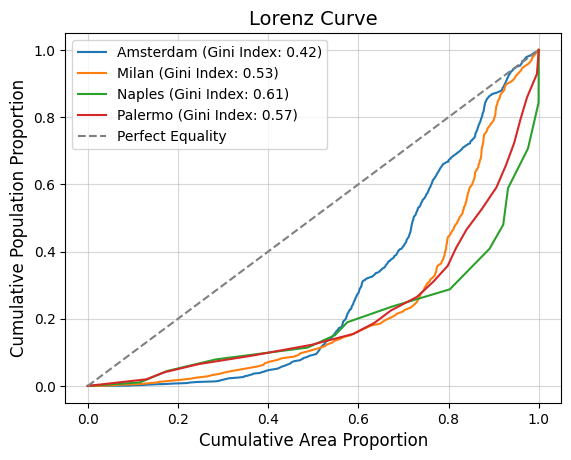

Gini Coefficients:
Amsterdam: 0.42
Milan: 0.53
Naples: 0.61
Palermo: 0.57


In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

# Specify the folder containing your CSV files
folder_path = "evcs_gini_2/"  # Replace with your folder path
file_paths = glob.glob(folder_path + "*.csv")  # Get all CSV files in the folder

gini_results = {}

# Loop through each file
for file_path in file_paths:
    # Extract city name from file name (e.g., "city_a.csv" -> "City A")
    city_name = file_path.split("\\")[-1].split(".")[0].replace("_", " ").title()
    
    # Load data from a CSV file
    data = pd.read_csv(file_path)

    # Extract relevant columns
    population_ratios = data['Pop_ratio'].values
    area_ratios = data['Area_ratio'].values
    population_coverage = data['Pop_Cov_Per'].values 
    area_coverage = data['Area_Cov_Per'].values
    population_to_area_ratios = data['p2a'].values 

    population_coverage_normalized = population_coverage / np.sum(population_coverage) 

    # Sort by population-to-area ratio
    sorted_indices = sorted(range(len(population_coverage_normalized)), key=lambda i: population_coverage_normalized[i])

    # Sort by population-to-area ratio (or any other criterion)
    #sorting_key = weighted_population / weighted_area
    #sorted_indices = sorted(range(len(sorting_key)), key=lambda i: sorting_key[i])
    sorted_population = [population_coverage_normalized[i] for i in sorted_indices]
    sorted_area = [area_ratios[i] for i in sorted_indices]

    # Compute cumulative proportions
    cumulative_population = np.cumsum(sorted_population) 
    cumulative_area = np.cumsum(sorted_area) 
    # Include (0, 0) for Lorenz curve
    cumulative_population = np.insert(cumulative_population, 0, 0)
    cumulative_area = np.insert(cumulative_area, 0, 0)

    # Calculate area under Lorenz curve
    area_under_lorenz_curve = np.trapezoid(cumulative_population, cumulative_area)

    # Compute Gini coefficient
    gini_coefficient = 1 - 2 * area_under_lorenz_curve
    gini_results[city_name] = gini_coefficient

    # Plot Lorenz curve
    plt.plot(cumulative_area, cumulative_population, label=f'{city_name} (Gini Index: {gini_coefficient:.2f})')

# Plot perfect equality line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Perfect Equality')

# Customize plot
plt.title('Lorenz Curve', fontsize=14)
plt.xlabel('Cumulative Area Proportion', fontsize=12)
plt.ylabel('Cumulative Population Proportion', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.5)
plt.show()

# Print Gini coefficient
print("Gini Coefficients:")
for city, gini in gini_results.items():
    print(f"{city}: {gini:.2f}")

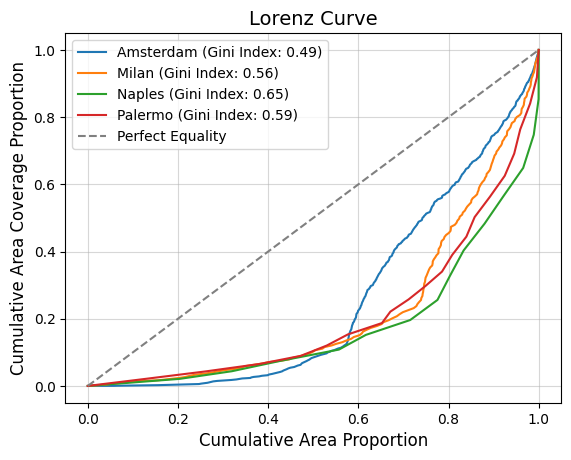

Gini Coefficients:
Amsterdam: 0.49
Milan: 0.56
Naples: 0.65
Palermo: 0.59


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

# Specify the folder containing your CSV files
folder_path = "evcs_gini_2/"  # Replace with your folder path
file_paths = glob.glob(folder_path + "*.csv")  # Get all CSV files in the folder

gini_results = {}

# Loop through each file
for file_path in file_paths:
    # Extract city name from file name (e.g., "city_a.csv" -> "City A")
    city_name = file_path.split("\\")[-1].split(".")[0].replace("_", " ").title()
    
    # Load data from a CSV file
    data = pd.read_csv(file_path)

    # Extract relevant columns
    population_ratios = data['Pop_ratio'].values
    area_ratios = data['Area_ratio'].values
    population_coverage = data['Pop_Cov_Per'].values 
    area_coverage = data['Area_Cov_Per'].values
    population_to_area_ratios = data['p2a'].values 

    population_coverage_normalized = population_coverage / np.sum(population_coverage) 

    area_coverage_normalized = area_coverage / np.sum(area_coverage) 

    # Sort by population-to-area ratio
    sorted_indices = sorted(range(len(area_coverage_normalized)), key=lambda i: area_coverage_normalized[i])

    # Sort by population-to-area ratio (or any other criterion)
    #sorting_key = weighted_population / weighted_area
    #sorted_indices = sorted(range(len(sorting_key)), key=lambda i: sorting_key[i])
    sorted_area_cov_n = [area_coverage_normalized[i] for i in sorted_indices]
    sorted_area = [area_ratios[i] for i in sorted_indices]

    # Compute cumulative proportions
    cumulative_area_cov_n = np.cumsum(sorted_area_cov_n) 
    cumulative_area = np.cumsum(sorted_area) 
    # Include (0, 0) for Lorenz curve
    cumulative_area_cov_n = np.insert(cumulative_area_cov_n, 0, 0)
    cumulative_area = np.insert(cumulative_area, 0, 0)

    # Calculate area under Lorenz curve
    area_under_lorenz_curve = np.trapezoid(cumulative_area_cov_n, cumulative_area)

    # Compute Gini coefficient
    gini_coefficient = 1 - 2 * area_under_lorenz_curve
    gini_results[city_name] = gini_coefficient

    # Plot Lorenz curve
    plt.plot(cumulative_area, cumulative_area_cov_n, label=f'{city_name} (Gini Index: {gini_coefficient:.2f})')

# Plot perfect equality line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Perfect Equality')

# Customize plot
plt.title('Lorenz Curve', fontsize=14)
plt.xlabel('Cumulative Area Proportion', fontsize=12)
plt.ylabel('Cumulative Area Coverage Proportion', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.5)
plt.show()

# Print Gini coefficient
print("Gini Coefficients:")
for city, gini in gini_results.items():
    print(f"{city}: {gini:.2f}")